In [1]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
memory = InMemorySaver()

In [3]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]

In [4]:
def node_a(state: State) -> Command[Literal["b", END]]:
    print(f"Adding 'A' to {state['nlist']}")
    admin = interrupt(f"interrupt!!!")
    print("print admin input: ", admin)
    if admin == "approve":
        next_node = "b"
        select = "b"
    else:
        next_node = END
        select = "q"
        
    return Command(
        update = State(nlist = [select]),
        goto = [next_node]
    )

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    return(State(nlist = ["B"]))

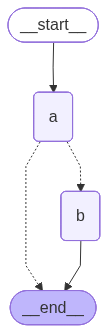

In [5]:
builder = StateGraph(State)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)

# Add edges
builder.add_edge(START,"a")
builder.add_edge("b", END)

# Compile and display
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
initial_state = State(
    nlist = ["Initial String:"]
)
config = {"configurable": {"thread_id": "1"}}
result = graph.invoke(initial_state, config)
if '__interrupt__' in result:
    print(f"Interrupt:{result}")
    msg = result['__interrupt__'][-1].value
    print(msg)
    human = input(f"\n{msg}: ")

    human_response = Command(
        resume = human
    )
    result = graph.invoke(human_response, config)

Adding 'A' to ['Initial String:']
Interrupt:{'nlist': ['Initial String:'], '__interrupt__': [Interrupt(value='interrupt!!!', id='9600d9f48b107275e5d1a3c37e93c67a')]}
interrupt!!!



interrupt!!!:  reject


Adding 'A' to ['Initial String:']
print admin input:  reject
